In [681]:
import matplotlib.pyplot as plt
import xarray as xr
import numpy as np
from physics_equations import specific_humidity_from_rh
import profiles_and_cloud_heights as profiles
from constants import g,alpha
import interpolation_lcl as interp
from autoconversion_rate import thresh
import autoconversion_rate as ar
from GB84_eqs import f as flux, rho_m,flux_2
import updraft_emmanuel
from updraft_emmanuel import w_parcel 
import new_rainfall_scheme as nr
import top_outflow as outflow

## Loading the data

Choose the time interval for which the model is to be run.

In [682]:
#time to check
slice_str = "2024-07-02T00:00:00, 2024-07-03T23:59:00"
slice_tuple = tuple(slice_str.split(", "))


Read the data which are to be used as inputs. The existing code uses a combined dataset from ERA5 surface values and ERA5 atmospheric profiles. The surface variables include the temperature, pressure, dew point temperature and vapor specific humidity and the profiles are of temperature,pressure and vapor specific humidity. Then, only the data corresponding to the desired time interval are selected.

In [683]:
data_era = xr.open_dataset(r'..\data\model_inputs\ERA5\ERA5combined_profile_data.nc')
data_era = data_era.sel(valid_time=slice(*slice_tuple))

Storing the time values and the timestep.

In [684]:
time = data_era.sel(valid_time=slice(*slice_tuple)).valid_time
dt_seconds = np.diff(time).astype('timedelta64[s]').astype(float)

#### Environmental profiles and inputs

In [685]:
T_air = data_era.temperature.values
p_air = data_era.pressure.values
Z = data_era.height.values
T_d = data_era.dew_point_temperature.values
q_v_air = data_era.specific_humidity.values

#### Parsivel rainfall data

Reading and storing the Parsivel 1 rainfall measurements from Cabauw, which are to be used for the assessment of the model's performance and/or as inputs to the Kalman filter.

In [686]:
parsivel_1 = xr.open_dataset(r'..\data\Cabaw_parsivel\PAR001_Cabauw_202407.nc')
reference_date = np.datetime64("1970-01-01")

# Convert minutes into datetime
datetime_values = reference_date + parsivel_1.epoch_time.astype("timedelta64[s]")
parsivel_1['time'] = datetime_values


rain_rate = parsivel_1.rainfall_rate_32bit.sel(time=slice(*slice_tuple))
hourly_avg = rain_rate.resample(time='1H').mean()

c:\Users\chari\miniconda3\envs\mude\Lib\site-packages\xarray\groupers.py:490: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  self.index_grouper = pd.Grouper(


## Running the model

### Parcel Profiles

Store the sizes for creating empty arrays

In [687]:
rows = T_air.shape[0]
cols = T_air.shape[1]

Creating empty arrays (either of size (time,height) or (time)) for storing the model outputs. *temp_parcel* is the parcel temperature profile resulting by solving the thermodynamic equations implemented in the model, while *T_v_moist* and *q_v_parcel* are the resulting virtual temperature and moisture profiles of the parcel. *p_s*, *T_s* and *lcl_index* are the pressure, temperature and index at the LCL level. All the other arrays serve as the expansion of the current environmental profiles by 1 (time,height+1), so that the exact values of the meteorological variables at the LCL are stored. 

In [688]:
T_arr = np.zeros((T_air.shape))
p_s = np.zeros(rows)    #cloud base pressure (time)
T_s = np.zeros(rows)    #cloud base temperature (time)
lcl_index = np.zeros(rows) #lcl index (time)

## empty arrays for storing the interpolated profiles (time, height+1)
temp_parcel = np.zeros((rows,cols+1))  # new parcel temperature (time, height+1)
my_temp_new = np.zeros((rows,cols+1))   # new temperature profile (time, height+1)
p_new = np.zeros((rows,cols+1))         # new pressure profile (time, height+1)
q_v_new = np.zeros((rows,cols+1))       # new specific humidity profile (time, height+1)
Z_new = np.zeros((rows,cols+1))         # new height profile (time, height+1)

## empty arrays for storing the outputs
T_v_moist = np.zeros((rows,cols+1))
q_v_parcel = np.zeros((rows,cols+1))
Z_b = np.zeros(rows)


Implementing the model functions to calculate the temperature and humidity profiles.

1. Using the *profiles_and_cloud_heights.py*, the parcel temperature profile is calculated, as well as the LCL variables of interest.
2. Using the *interpolation_lcl.py*, all the parcel and environmental profiles are updated so that we have exact values for all the meteorological
   variables of interest at the LCL.
3. With *profiles_and_cloud_heights.py* parcel humidity and virtual temperature profiles are calculated. 

In [689]:
#import profiles_and_cloud_heights as profiles
#import interpolation_lcl as interp

theta_type = 'theta_l'       #choose which approach to follow for the conserved potential temperature

for i in range(0,T_air.shape[0]):
    print(i)
    #calculating the profiles
    T_arr[i,:],lcl_index[i],p_s[i],T_s[i] = profiles.Temp_prof(T_air[i,0],p_air[i,0],T_d[i],p_air[i],theta_type=theta_type)

    #interpolation at the lcl level
    temp_parcel[i], p_new[i], Z_new[i], lcl_index[i], my_temp_new[i], q_v_new[i] = interp.insert_lcl_values(T_arr[i,:],p_air[i],Z[i],int(lcl_index[i]),T_s[i],p_s[i],T_air[i,:],q_v_air[i,:])

    #calculating the virtual temperature profile of the parcel
    T_v_moist[i,:],q_v_parcel[i,:] = profiles.T_v(T_d[i],p_new[i,0],p_new[i],temp_parcel[i,:],int(lcl_index[i]),theta_type=theta_type)

0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
42
43
44
45
46
47


Calculate the environmental virtual temperature profiles

In [690]:
T_v_env = my_temp_new*(1+0.61*q_v_new)

### Cloud Heights

Calculating the location of the LFC, which is given by the lfc_index, as well as if the conditions allow the parcel to reach it. If so, then the first value of the LFC_index variable will print "yes" and we are storing 1. Otherwise, we get "no" and 0 is stored.

In [691]:
LFC_index = np.zeros((rows,2))  #empty array for storing the LFC index

for i in range(0,rows):
    flag, lfc_idx = profiles.find_lfc(
        T_v_moist[i], T_v_env[i], Z_new[i], int(lcl_index[i])
    )
    # store the numeric index in column 0
    LFC_index[i, 1] = lfc_idx

    # if you also want a numeric code for “yes” / “no”, e.g. 1/0:
    LFC_index[i, 0] = 1 if flag.lower() == "yes" else 0

Finding the cloud top height and pressure and the resulting cloud depth, again by calling *profiles_and_cloud_heights.py*.

In [692]:
#empty arrays for storing the outputs
Z_c = np.zeros(rows)
Z_t = np.zeros(rows)
p_t = np.zeros(rows)

#finding cloud top and cloud depth
for i in range(0,rows):
    Z_c[i],Z_t[i],p_t[i] = profiles.cloud_top(LFC_index[i],Z_new[i],Z_new[i,int(lcl_index[i])],p_new[i],T_v_moist[i],T_v_env[i],temp_parcel[i])

In [693]:
entraintment_rate = 3e-4
from profiles_and_cloud_heights import profiles_entrainment
T_parcel_new = np.zeros((rows,cols+1)) 
q_t_parcel_new = np.zeros((rows,cols+1))

for i in range(0,rows):
    print(i)
    if Z_c[i] <= 100:
        T_parcel_new[i] = temp_parcel[i]
        q_t_parcel_new[i] = q_v_new[i]
    else:
        T_parcel_new[i],q_t_parcel_new[i] = profiles_entrainment(T_s[i], T_d[i], my_temp_new[i], temp_parcel[i], p_s[i], p_new[i], q_v_new[i], Z_new[i,], int(lcl_index[i]), 1/Z_c[i], theta_type)


0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25


c:\Users\chari\Home\TU Delft\TU-Delft\thesis\rainmodel_conc\new_model\physics_equations.py:36: RuntimeWarning: invalid value encountered in power
  np.exp(34.494 - 4924.99 / (T_C + 237.1)) / (T_C + 105) ** 1.57,


26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
42
43
44
45
46
47


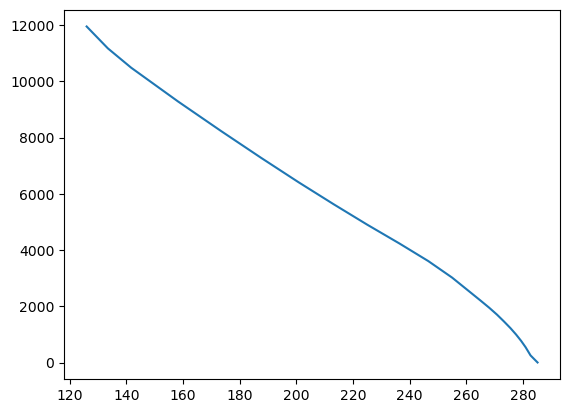

In [694]:
plt.plot(T_parcel_new[23],Z_new[23])

In [695]:
q_l_new = np.zeros((rows,cols+1))
q_v_parcel_new = np.zeros((rows,cols+1))
for i in range(0,rows):
    q_l_new[i],q_v_parcel_new[i] = profiles.humidity_entraintment(T_d[i],p_new[i,0],p_new[i],T_parcel_new[i],q_t_parcel_new[i],int(lcl_index[i]))

In [696]:
print(q_v_parcel[20])
print(q_t_parcel_new[1])
print(q_l_new[1])

[7.41337386e-03 7.41337386e-03 7.41337386e-03 7.41337386e-03
 7.34222132e-03 7.00395700e-03 6.63411671e-03 6.26451184e-03
 5.89565432e-03 5.52813126e-03 5.16261419e-03 4.79083475e-03
 4.39960785e-03 3.63798780e-03 2.91486195e-03 2.24531487e-03
 1.64628178e-03 1.13464057e-03 7.23783211e-04 4.19211524e-04
 2.15115288e-04 9.45007001e-05 3.36778385e-05 1.80918886e-05
 8.85307721e-06]
[1.02829793e-02 8.72043148e-03 8.18556640e-03 8.52921978e-03
 8.00183788e-03 7.57601485e-03 7.25787878e-03 6.95609301e-03
 6.59533218e-03 6.33517653e-03 6.31608255e-03 5.99305704e-03
 5.43275382e-03 3.97694018e-03 3.83839197e-03 3.50386440e-03
 2.75712297e-03 1.62890484e-03 1.20009365e-03 8.38612672e-04
 3.83070292e-04 1.94373119e-04 8.48687632e-05 3.28897149e-05
 1.26079558e-05]
[0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00
 0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00
 0.00000000e+00 0.00000000e+00 0.00000000e+00 1.73748446e-05
 0.00000000e+00 0.00000000e+00 0.00000000e+00 3.899

In [697]:
lcl_index[20]

4.0

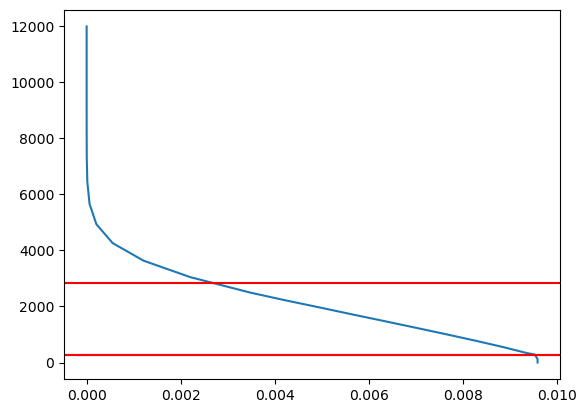

In [698]:
#plt.plot(q_v_new[10],Z_new[10])
plt.plot(q_v_parcel_new[10],Z_new[10])
plt.axhline(Z_new[10,int(lcl_index[10])],color='red')
plt.axhline(Z_new[10,int(LFC_index[10,1])],color='red')
plt.axhline(Z_t[10],color='red')
#plt.plot(q_v_parcel[10],Z_new[10])

In [699]:
T_v_moist_new = T_parcel_new*(1+0.61*q_v_parcel_new - q_l_new)

In [700]:
q_t_parcel_new[22]
#q_l_new[22]

array([7.60221798e-03, 7.60221798e-03, 7.60221798e-03, 7.57788659e-03,
       7.49402904e-03, 7.38148473e-03, 7.19547815e-03, 6.95802565e-03,
       6.69828215e-03, 6.43638531e-03, 6.17319476e-03, 5.83762093e-03,
       5.35055410e-03, 4.19171503e-03, 3.69957314e-03, 3.29302624e-03,
       2.80973377e-03, 1.93952176e-03, 1.36132919e-03, 8.70506361e-04,
       4.99614582e-04, 2.55817400e-04, 1.57413382e-04, 1.06103779e-04,
       6.32093306e-05])

In [701]:
LFC_index = np.zeros((rows,2))  #empty array for storing the LFC index

for i in range(0,rows):
    flag, lfc_idx = profiles.find_lfc(
        T_v_moist_new[i], T_v_env[i], Z_new[i], int(lcl_index[i])
    )
    # store the numeric index in column 0
    LFC_index[i, 1] = lfc_idx

    # if you also want a numeric code for “yes” / “no”, e.g. 1/0:
    LFC_index[i, 0] = 1 if flag.lower() == "yes" else 0

In [702]:
#empty arrays for storing the outputs
Z_c_new = np.zeros(rows)
Z_t_new = np.zeros(rows)
p_t_new = np.zeros(rows)

#finding cloud top and cloud depth
for i in range(0,rows):
    Z_c_new[i],Z_t_new[i],p_t_new[i] = profiles.cloud_top(LFC_index[i],Z_new[i],Z_new[i,int(lcl_index[i])],p_new[i],T_v_moist_new[i],T_v_env[i],T_parcel_new[i])

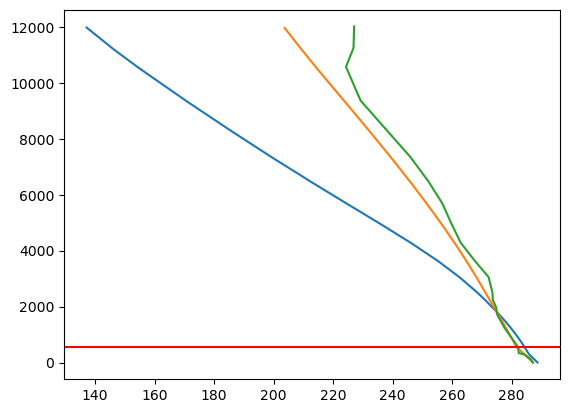

In [703]:
plt.plot(T_parcel_new[10],Z_new[10])
plt.plot(temp_parcel[20],Z_new[20])
plt.plot(my_temp_new[20],Z_new[1])
plt.axhline(y=Z_new[20,int(lcl_index[20])],color='red')
#plt.ylim(0,2000)

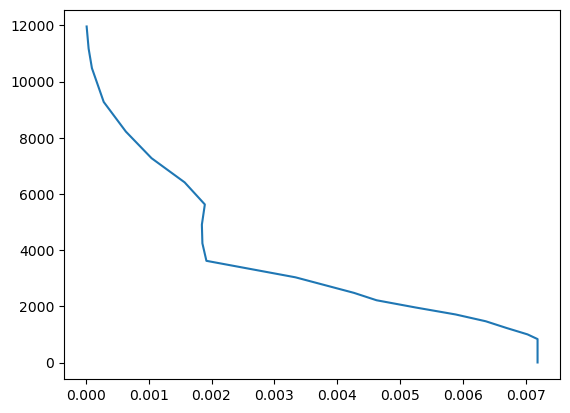

In [704]:
index = 18
plt.plot(q_t_parcel_new[index],Z_new[index])

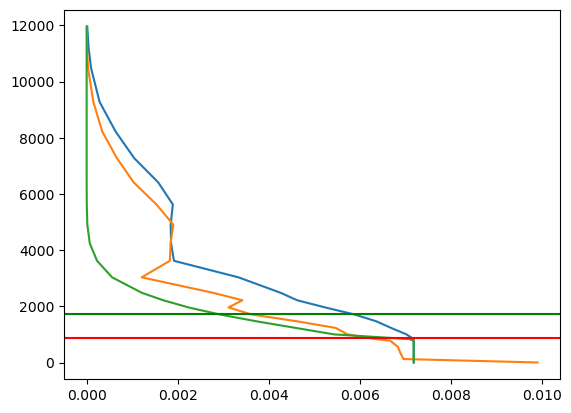

In [705]:
plt.plot(q_t_parcel_new[index],Z_new[index])
plt.plot(q_v_new[index],Z_new[index])
plt.plot(q_v_parcel_new[index],Z_new[index])
plt.axhline(y=Z_t[index],color='green')
plt.axhline(y=Z_t_new[index],color='red')

### Updraft speed

Using the parcel and environmental virtual temperature profiles, we calculate the parcel updraft velocity profile by calling the *updraft_emmanuel.py*. To do so, we have to first find the index of cloud top height. 

In [706]:
#import updraft_emmanuel

w_parcel_max= np.zeros(rows)

for i in range(0,rows):
    #print(i)
    if Z_t_new[i] == 0:
        top_index = 0
    else:
         top_index = np.argmax((Z_t_new[i] - Z_new[i]) <= 0)

    w_parcel_max[i],CAPE = updraft_emmanuel.w_parcel(p_new[i],T_v_moist_new[i],T_v_env[i],LFC_index[i,1],p_t_new[i],top_index)
    print(CAPE)

0
1.6048409849028051
2.635178651703815
8.956325141946916
6.110644670977682
1.2911138857925606
10.883234273508242
16.86100305081341
17.911353033405764
25.98649495234308
16.39130626704283
10.922828658965003
1.9388822618111612
5.034148591808096
8.363940682084648
2.4096370972691297
2.3219922181233876
3.927667951231284
4.11430495963489
2.351375153318024
0
9.91362764701234
0
0
0
0
8.983285934311283
0
6.986913137426638
0.2228742799644175
0
1.2046943051617833
1.7298595609584735
0.2842581940818152
50.15355496557923
35.30453142071528
29.460465515836994
31.364688799238614
14.741982641448116
6.367989355235753
5.288675840854613
3.102843260368436
1.3143897097084611
0.8770742064202977
0
0
15.468332652033325
0.05500789045954393


from constants import R_dry
def w_parcel(p,T_v_moist,T_v_env,lfc_index,p_t,top_index):

    """
    the scheme for calculating the maximum updraft velocity (Emanuel 1991)

    Parameters:
        p: pressure profile  [Pa]"
        T_v_moist: parcel virtual temperature profile [K]"
        T_env: environment virtual temperature profile  [K]"
        lfc_index: index of the LFC
        top_index: index of the top of the cloud

    Returns:
        w_parcel_max: maximum updraft velocity [m/s]
        CAPE: convective available potential energy
    """
    
    if top_index>1 and top_index>int(lfc_index):
    #implementation of the CAPE equation and integration
        delta_ln_p = -np.diff(np.log(p[int(lfc_index):top_index+1]))
        
        buoyancy = R_dry * (T_v_moist - T_v_env)[int(lfc_index):top_index]
        print(buoyancy)
        CAPE = np.sum(buoyancy * delta_ln_p)
        w_parcel_max = np.sqrt(2 * CAPE)
    else:
        w_parcel_max = 0
        CAPE = 0
    return w_parcel_max,CAPE
if Z_t_new[138] == 0:
        top_index = 0
else:
         top_index = np.argmax((Z_t_new[138] - Z_new[138]) <= 0)
print(top_index)
w_parcel(p_new[138],T_v_moist_new[138],T_v_env[138],LFC_index[138,1],p_t_new[138],top_index)

In [707]:
n_nans = np.isnan(q_t_parcel_new).sum()
print(f"Number of NaNs in q_l_new: {n_nans}")

Number of NaNs in q_l_new: 0


### State calculation and update

Calculating the state evolution with time. The moisture flux in the cloud system is calculated using the *GB84.py*, while the outflow 

In [708]:
#import autoconversion_rate as ar
#from GB84_eqs import f as flux, rho_m
#import top_outflow as outflow

#empty arrays for storing condensation flux and state values
f_arr = np.zeros(rows)
X =np.zeros(rows)


for i in range(0,rows):
    print(i)
    if Z_t_new[i] == 0:
        top_index = 0
    else:
         top_index = np.argmax((Z_t_new[i] - Z_new[i]) <= 0)

    w_avg = w_parcel_max[i]/2
    rho = rho_m(T_s[i],my_temp_new[i,min(top_index,cols-1)],p_s[i],p_t_new[i])

    if w_parcel_max[i] == 0:
        # no convection == no flux
        f_arr[i] = 0
    else:
        f_arr[i] = flux_2(rho,w_avg,q_l_new[i],int(lcl_index[i]),top_index)

    if i<rows-1:
        if X[i]/Z_c_new[i] > 2.5e-3:        #capping the X values so that they don't abnormally high
            X[i] = 2.5e-3*Z_c_new[i]

    #state update
        X[i+1] = X[i] +f_arr[i]*dt_seconds[i] - ar.autoconoversion_rate(X[i],Z_c_new[i],thresh)*dt_seconds[i] - outflow.O_t(X[i],top_index,Z_b[i],Z_new[i],w_parcel_max[i],int(LFC_index[i,1]),dt_seconds[i])*dt_seconds[i]
        #print(outflow.O_t(X[i],top_index,Z_b[i],Z_new[i],w_parcel_max[i],int(LFC_index[i,1]),dt_seconds[i])*dt_seconds[i])
        X[i+1] = max(0,X[i+1])

0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
42
43
44
45
46
47


#### Rainfall rates

In [709]:
#import autoconversion_rate as ar
#import new_rainfall_scheme as nr

# empty arrays for storing the rainfall rates and the size distribution parameters

R = np.zeros(rows)  #rainfall rate at the cloud base
P = np.zeros(rows)  #precipitation rate at the surface

lambda_arr = np.zeros(rows)     #slope parameter of Gamma distribution
mu_result_arr = np.zeros(rows)  #shape parameter of Gamma distribution
Dc_arr = np.zeros(rows)         #critical diameter for evaporation


for i in range(0,rows):
    R[i] = ar.autoconoversion_rate(X[i],Z_c_new[i],thresh)
    if R[i]<1e-5:
        P[i] = 0
    else:
        Lambda_result = nr.solve_lambda_mu_dependent(R[i], alpha, w_parcel_max[i]/2*100)
        mu_result = nr.mu_from_lambda(Lambda_result)
        print(mu_result,Lambda_result)
        D_critical = ar.critical_diameter(my_temp_new[i,0], p_new[i,0], T_d[i], Z_new[i,int(lcl_index[i])], Z_c_new[i],w_parcel_max[i]/2*100).calculate_D_c()
        P[i] = nr.precipitation_rate(ar.autoconoversion_rate(X[i],Z_c_new[i],thresh), mu_result, Lambda_result, D_critical*100,w_parcel_max[i]/2*100,alpha)

6.921324374348967 82.07958539619831
6.892001829618867 81.77119930128785
13.820939571933582 166.75080323869312
5.240095501158742 64.88654289314583
5.4243891440025545 66.72502745430297
4.675962999261837 59.32454454137209
6.617971915667504 78.90453419977655
7.679777017373028 90.17061270015114
13.10103070693256 156.4065165009673
13.047839385366748 155.66121811534336
12.892618290312479 153.50039194149429
15.596593488608448 194.73013821171494
15.542538605901079 193.8160084829722
14.525175730656212 177.38260365520148
13.89949249722494 167.9101834164633
14.331479229269739 174.40331080167905
8.69223514221735 101.3384296218789
2.0761624639532332 34.85164382817282
3.2849697857971156 46.00684737567051
3.6988839421208297 49.91343913548102
6.957170111930329 82.45701167133565
11.060245780715825 129.40154434858843
12.29547295501979 145.37376912626638
13.206611028976958 157.8933114245024
13.64673257148538 164.20196305925234
9.383866985634224 109.23299782124249


## Visualizing the outputs

#### Rainfall rate

Text(0.5, 0, 'Date (MM-DD) - Time (HH)')

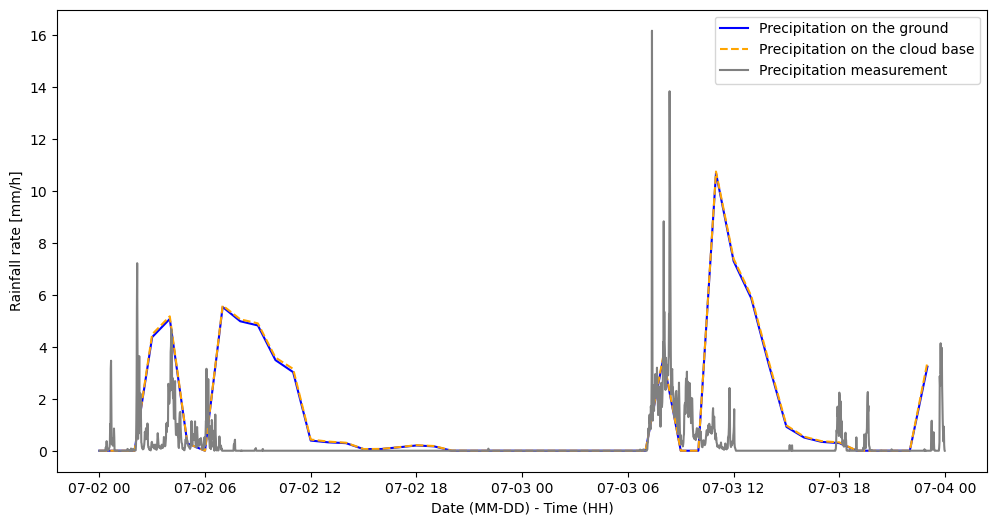

In [710]:
plt.figure(figsize=(12,6))
plt.plot(time,P*3600,label='Precipitation on the ground',color='blue')
plt.plot(time,R*3600,color='orange',linestyle='--',label='Precipitation on the cloud base')
plt.plot(rain_rate.time,rain_rate,color='gray',label='Precipitation measurement')
plt.legend()
plt.ylabel('Rainfall rate [mm/h]')
plt.xlabel('Date (MM-DD) - Time (HH)')

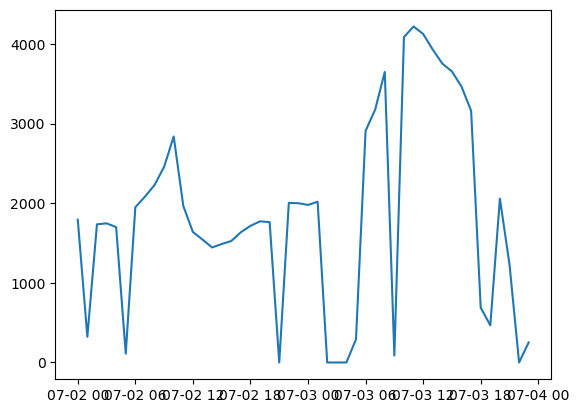

In [711]:
plt.plot(time,Z_t)

#### Virtual Temperature profiles at different times

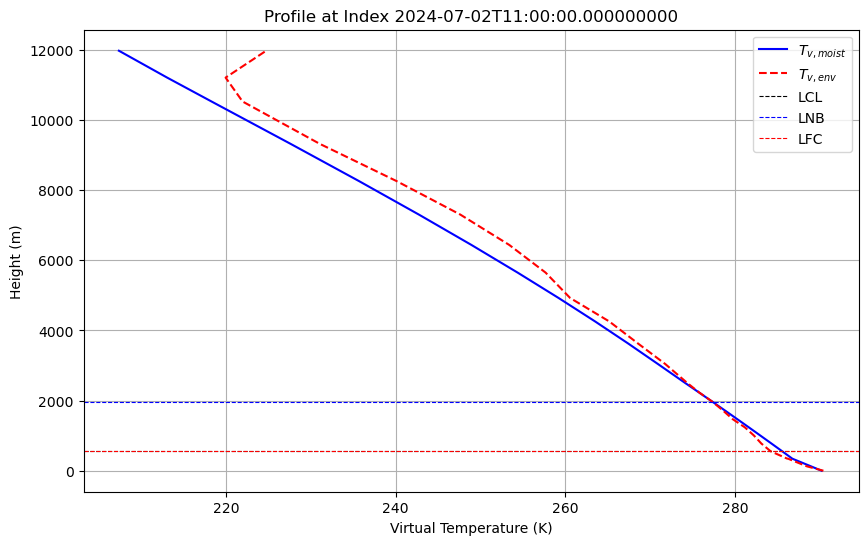

In [712]:
index_2 = 11
fig,ax2 = plt.subplots(figsize=(10,6))
ax2.plot(T_v_moist[index_2], Z_new[index_2], label='$T_{v,moist}$', color='blue')
ax2.plot(my_temp_new[index_2] * (1 + 0.61 * q_v_new[index_2]), Z_new[index_2], 
        label='$T_{v,env}$', color='red', linestyle='--')
ax2.set_xlabel('Virtual Temperature (K)')
ax2.axhline(y=Z[index_2,int(lcl_index[index_2])], color='black', linestyle='--',linewidth='0.8',label='LCL')
ax2.axhline(y=Z_t[index_2], color='blue', linestyle='--',linewidth='0.8',label='LNB')
ax2.axhline(y=Z[index_2,int(LFC_index[index_2,1])], color='red', linestyle='--',linewidth='0.8',label='LFC')
ax2.set_xlabel('Virtual Temperature (K)')
ax2.set_ylabel('Height (m)')
ax2.set_title(f'Profile at Index {time[index_2].values}')
ax2.legend()
ax2.grid(True)

#### Cloud top and base

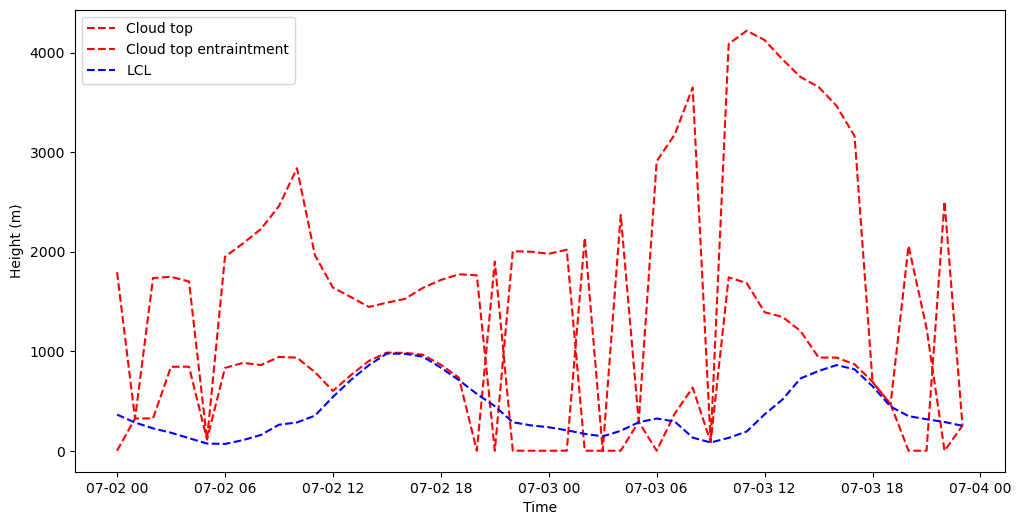

In [713]:
plt.figure(figsize=(12,6))
plt.plot(time,Z_t,color='red',linestyle='--',label='Cloud top')
plt.plot(time,Z_t_new,color='red',linestyle='--',label='Cloud top entraintment')
plt.plot(time,Z_new[np.arange(Z_new.shape[0]),lcl_index.astype(int)],color='blue',linestyle='--',label='LCL')
plt.ylabel('Height (m)')
plt.xlabel('Time')
plt.legend()

#### Updraft velocity

Text(0.5, 0, 'Date (MM-DD) - Time (HH)')

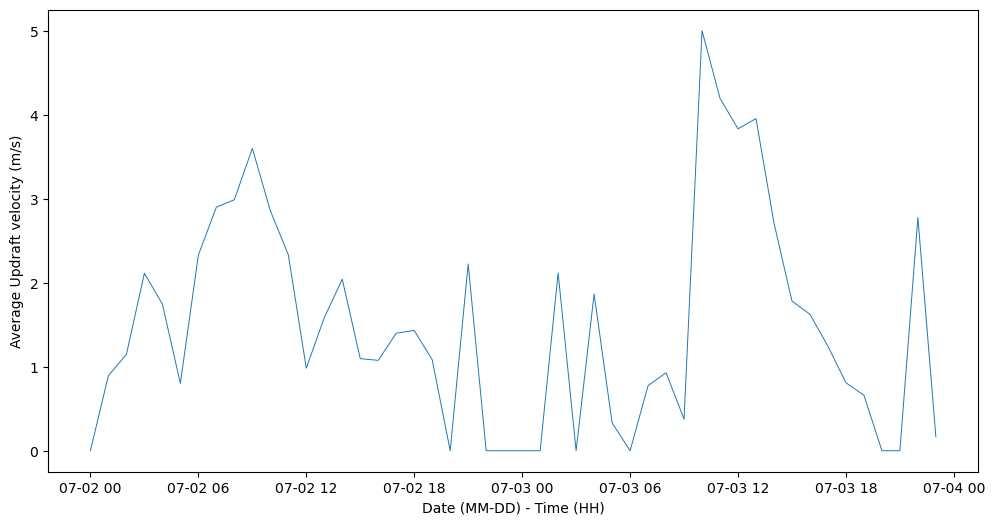

In [714]:
plt.figure(figsize=(12,6))
plt.plot(time,w_parcel_max/2,linewidth=0.7)
plt.ylabel('Average Updraft velocity (m/s)')
plt.xlabel(('Date (MM-DD) - Time (HH)'))

#### LWC and LWP(state)

(0.0, 10.0)

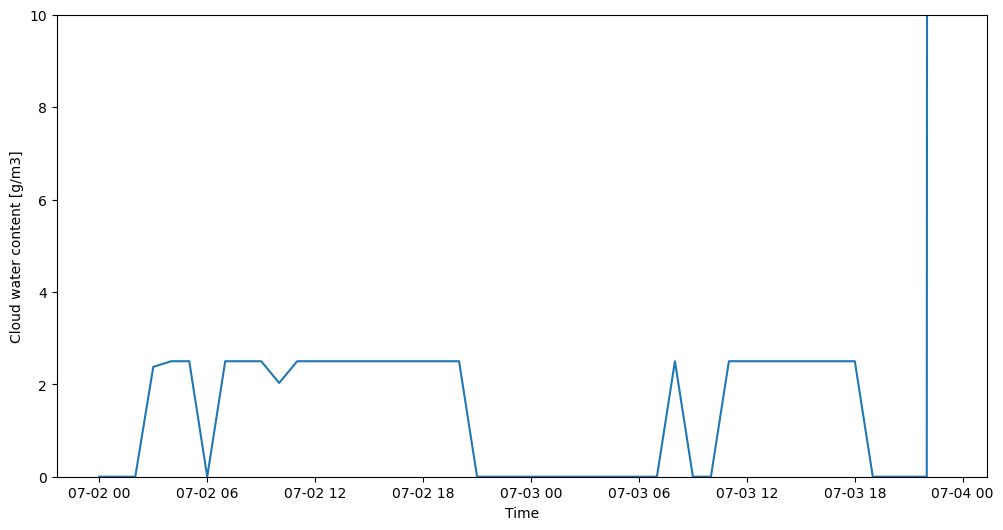

In [715]:
plt.figure(figsize=(12,6))
plt.plot(time,X/Z_c_new*1000)
plt.ylabel('Cloud water content [g/m3]')
plt.xlabel('Time')
plt.ylim(0,10)

Text(0, 0.5, 'Cloud water content [kg/m2]')

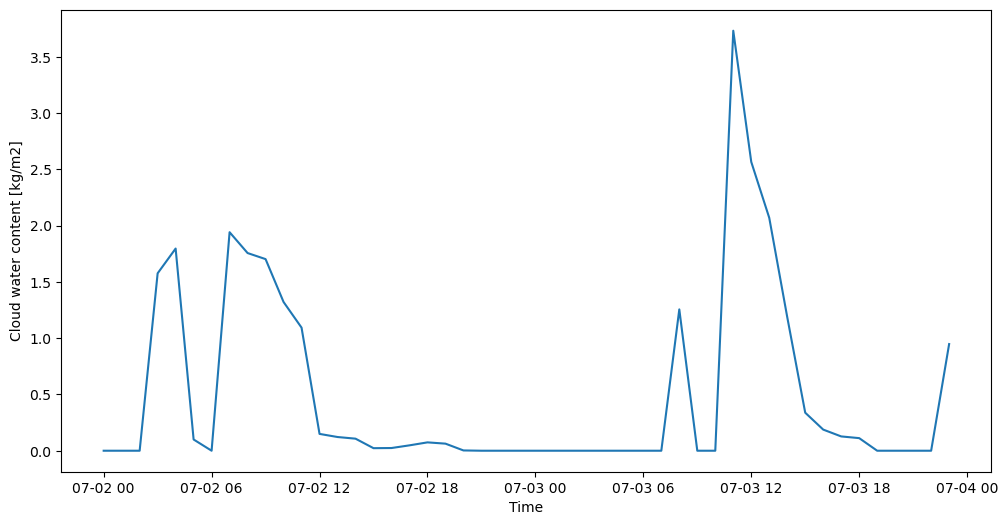

In [716]:
plt.figure(figsize=(12,6))
plt.plot(time,X)
plt.xlabel('Time')
plt.ylabel('Cloud water content [kg/m2]')

#### Size distribution

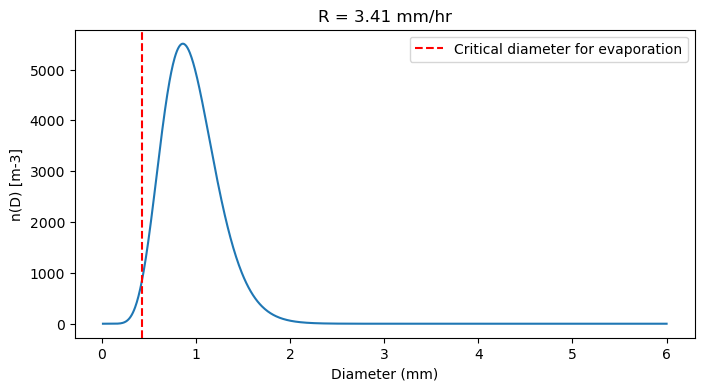

In [717]:
D = np.linspace(0.001,0.6,1000)
N = 6e4 * np.exp(3.2 * mu_result)* D**(mu_result)*np.exp(-Lambda_result*D)#plt.ylim(0,100)

plt.figure(figsize=(8,4))
plt.title(f'R = {R[i] * 3600:.2f} mm/hr')
plt.plot(D*10,N)
plt.axvline(x=D_critical*1000,color='r',linestyle='--',label='Critical diameter for evaporation')
plt.xlabel('Diameter (mm)')
plt.ylabel('n(D) [m-3]')
plt.legend()